# Prepare XES
XES (eXtensible Event Stream) is the standard XML-based file format used to store and exchange event logs for PM4Py (Process Mining for Python). 

In this notebook we construct XES process event logs from the agent traces. The agents run in AgentCore Runtime. Their traces are produced through OpenTelemetry to Amazon XRay.

This notebook transforms XRay traces to XES.

## XES vs CSV
Besides XES, pm4py also supports CSV event logs. CSV has pros and cons.

Pros of CSV:
- Easier to scale large events logs. We haven't tested how well pm4py ingests a huge XES file. Does it use a stream-based XML parser? DOM parsers want to load the whole XML DOM tree into memory at once. Not suitable for a huge event log. A large CSV can be written or read without taxing memory using normal file IO.
- Easier to combine events of the same case across different files. This is especially important for long-lived processes, where events are scattered over weeks, months, or years. Through Pandas or Spark ETL, events can be grouped by case from different CSV files. This is harder with XES. 

Cons of CSV:
- XES form makes it easier to express case-level attributes, including multi-valued attributes. CSV makes this harder because of its flat structure.

## XRay retention and long-lived processes
XRay retains traces for 30 days. That means you have to run this notebook's conversion tool before the trace is removed, or else you will lose those events. For short-lived agentic flows (such as the research and market-intelligence agents), that's workable: schedule this run every day and lose nothing.

For a long-lived agents like trusteeship, care is needed to capture all events of the case. This conversion utility makes the simplifying assumption that the full process completes within the 30-day window. If the trusteeship process should exceed 30 days, its full event log can be captured in one of the following ways:

- XRay is transformed to a CSV file on a periodic basis. The full case is merged from separate CSV files. (**Straightforward**)
- XRay is transformed to an XES file on a periodic basis. The full case is merged from separate XES files. (**Harder**)
- The trusteeship agent keeps state, including a trace of its activities, in a DynamoDB table. Reconstruct this table instead of from XRay. To avoid a table scan, you need to know the partition key of the case: application_id. You could discover each application_id from that period's XRay trace. (**Straightforward but cumbersome**)

## Agents of interest. 
For each, what from the trace do we map to a process activity type? What trace attributes should we build a case from? 

In [6]:
AGENT_TASK_PATTERN={
    "research_agent_react.DEFAULT": { 
        "activity_type": "execute_tool",
        "case_attributes": ["session", "trace"]
    },
    "trusteeship_application_agent.DEFAULT": {
        "activity_type": "execute_tool",
        "case_attributes": ["application"]
    },
    "market_intel_agent.DEFAULT": {
        "activity_type": "invoke_agent",
        "case_attributes": ["trace"]
    }
}

## Code to fetch traces from XRay and write as XES

In [8]:
from __future__ import annotations

import argparse
import json
import logging
import sys
import copy
from dataclasses import dataclass, field
from datetime import datetime, timezone
from typing import Iterable, Iterator
from xml.etree.ElementTree import Element, ElementTree, SubElement
from datetime import timedelta

import boto3

def write_metrics_to_xes(event_list, case_attribute, output_path):
    """
    Converts metrics data into a valid XES log with Lifecycle support.
    Input: A list of lists containing dictionaries with agent, trace, session, tool, etc.
    """
    XES_NS = "http://www.xes-standard.org/"
    log_el = Element("log", attrib={"xes.version": "1.0", "xmlns": XES_NS})

    SubElement(log_el, "extension", name="Concept", prefix="concept", uri=XES_NS + "concept.xesext")
    SubElement(log_el, "extension", name="Time", prefix="time", uri=XES_NS + "time.xesext")
    SubElement(log_el, "extension", name="Lifecycle", prefix="lifecycle", uri=XES_NS + "lifecycle.xesext")
    SubElement(log_el, "extension", name="Organizational", prefix="org", uri=XES_NS + "org.xesext")
    SubElement(log_el, "classifier", name="Activity", keys="concept:name")

    cases = {}
    for entry in event_list:
        case_id = entry.get(case_attribute)
        if case_id not in cases:
            cases[case_id] = []
        cases[case_id].append(entry)

    n_traces = 0
    n_events = 0

    for case_id, events in cases.items():
        trace_el = SubElement(log_el, "trace")
        SubElement(trace_el, "string", key="concept:name", value=str(case_id))
        
        # Sort chronologically by execution timeline to preserve sequence integrity
        events.sort(key=lambda x: x.get('end_time', 0))
        
        for entry in events:
            activity_name = entry.get('task', 'unknown_task')
            user = entry.get('user', 'unknown_user')
            
            # --- Single Atomic Event Block ---
            ev = SubElement(trace_el, "event")
            SubElement(ev, "string", key="concept:name", value=str(activity_name))
            SubElement(ev, "string", key="org:resource", value=str(user))
            
            # Using end_time as the explicit point of completion
            end_ts = datetime.fromtimestamp(entry.get('end_time', 0), tz=timezone.utc)
            SubElement(ev, "date", key="time:timestamp", value=end_ts.isoformat(timespec="milliseconds"))
            
            # Attach metrics and tracking metadata directly to this single event
            duration_val = float(entry.get('duration', 0.0))
            SubElement(ev, "float", key="duration_s", value=f"{duration_val:.3f}")
            SubElement(ev, "string", key="trace_id", value=str(entry.get('trace', '')))
            SubElement(ev, "string", key="session_id", value=str(entry.get('session', '')))
            
            n_events += 1  # Exactly one event counted
        n_traces += 1

    tree = ElementTree(log_el)
    try:
        from xml.etree.ElementTree import indent
        indent(tree, space="  ")
    except ImportError:
        pass 
        
    if len(cases) > 0: 
        tree.write(output_path, encoding="utf-8", xml_declaration=True)

def _parse_iso(s: str) -> datetime:
    s = s.replace("Z", "+00:00")
    dt = datetime.fromisoformat(s)
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return dt

def fetch_trace_ids(
    start: datetime,
    end: datetime,
    filter_expression: str | None = None,
    region: str = "us-east-1",
) -> list[str]:
    """Page through GetTraceSummaries and return matching trace IDs.
    Chunk requests automatically into 24-hour windows to bypass the AWS service limit."""
    client = boto3.client("xray", region_name=region)
    paginator = client.get_paginator("get_trace_summaries")
    
    all_ids: list[str] = []
    current_start = start

    while current_start < end:
        current_end = min(current_start + timedelta(hours=24), end)
        
        kwargs: dict = {"StartTime": current_start, "EndTime": current_end}
        if filter_expression:
            kwargs["FilterExpression"] = filter_expression
                    
        for page in paginator.paginate(**kwargs):
            all_ids.extend(s["Id"] for s in page.get("TraceSummaries", []))
        
        current_start = current_end
        
    return all_ids

def fetch_traces(trace_ids: Iterable[str], region: str = "us-east-1") -> Iterator[dict]:
    """Yield full trace records via BatchGetTraces (max 5 ids per call)."""
    client = boto3.client("xray", region_name=region)
    ids = list(trace_ids)
    for i in range(0, len(ids), 5):
        resp = client.batch_get_traces(TraceIds=ids[i:i + 5])
        yield from resp.get("Traces", [])

def extract_tool_metrics(raw_segments, distinct_agents):
    """
    Parses X-Ray segments and returns a list of tool executions.
    Format: [trace_id, session_id, tool_name, tool_duration]
    """
    for segment in raw_segments:
        # The Trace ID is usually at the top level of the segment wrapper
        # e.g., "1-6a03bccb-0095c96c2c9ff3c757f8ac40"
        trace_id = segment.get('Id', '')
        
        # Parse the stringified Document
        try:
            doc = json.loads(segment.get('Document', '{}'))
        except json.JSONDecodeError:
            continue

        # Extract Session ID from metadata
        metadata = doc.get('metadata', {})
        session_id = metadata.get('session.id', '')
        agent=doc.get('name')
        user_id = metadata.get('user_id', "")
        application_id = metadata.get('application_id', "")

        if (not agent) or not (agent in AGENT_TASK_PATTERN):
            continue

        if agent not in distinct_agents:
            distinct_agents[agent] = []

        def scan_for_tools(items):
            for item in items:
                span_name = item.get('name', '')
                task_name = None
                tp = AGENT_TASK_PATTERN[agent]["activity_type"]
                if span_name.startswith(tp):
                    task_name = span_name.replace(f"{tp} ", "").strip()
                if task_name:                    
                    # Calculate timing
                    start = item.get('start_time', 0)
                    end = item.get('end_time', 0)
                    duration = round(end - start, 4) if (end and start) else 0.0

                    distinct_agents[agent].append({
                        "agent": agent,
                        "trace": trace_id,
                        "session": session_id,
                        "task": task_name,
                        "user": user_id,
                        "application": application_id,
                        "duration": duration,
                        "start_time": start,
                        "end_time": end
                    })
                
                # Recurse through subsegments
                if 'subsegments' in item:
                    scan_for_tools(item['subsegments'])

        # Check root level subsegments
        if 'subsegments' in doc:
            scan_for_tools(doc['subsegments'])


## Run the conversion
First trace ids in the time interval specified

In [13]:
START_TIME_UTC="20260525T23:00:00"
END_TIME_UTC=None # current
REGION="us-east-1"
FILTER=None

start = _parse_iso(START_TIME_UTC)
end = _parse_iso(END_TIME_UTC) if END_TIME_UTC else datetime.now(timezone.utc)

trace_ids = fetch_trace_ids(start, end, FILTER, REGION)
#trace_ids #show the ids, but it's a lot


Now fetch each trace and convert to XES. Output is XML files in OUTDIR

In [14]:
OUTDIR="xeslogs"

distinct_agents={}
for raw in fetch_traces(trace_ids, REGION):
    extract_tool_metrics(raw['Segments'], distinct_agents)

import os
if not os.path.exists(OUTDIR):
    os.makedirs(OUTDIR)

for a in distinct_agents:
    for c in AGENT_TASK_PATTERN[a]['case_attributes']:
        # which agent, which case, how many, plus a sample of events
        print(f"{a} {c} {len(distinct_agents[a])}")
        print(distinct_agents[a][0:2])
        safe_file_name = a.replace(".", "_").replace(" ", "_") + f"_{c}.xes"
        output_file_path = os.path.join(OUTDIR, safe_file_name)
        write_metrics_to_xes(distinct_agents[a], c, output_file_path)

market_intel_agent.DEFAULT trace 134
[{'agent': 'market_intel_agent.DEFAULT', 'trace': 'becfdca21d81a1ef', 'session': '6719150f-dba2-404d-9a96-434693c8f479', 'task': 'synthesizer', 'user': '', 'application': '', 'duration': 3.0977, 'start_time': 1779752876.649642, 'end_time': 1779752879.7473283}, {'agent': 'market_intel_agent.DEFAULT', 'trace': 'becfdca21d81a1ef', 'session': '6719150f-dba2-404d-9a96-434693c8f479', 'task': 'graph_router', 'user': '', 'application': '', 'duration': 1.2005, 'start_time': 1779752875.448757, 'end_time': 1779752876.6492221}]


Produces these files
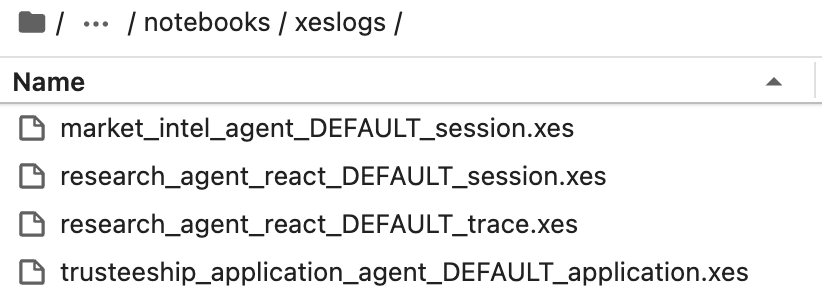